### Importação das bibliotecas


In [37]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import joblib


from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split,
)

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    auc,
    confusion_matrix,
    classification_report,
    precision_score,
    accuracy_score,
    recall_score,
    f1_score,
)

from fairlearn.metrics import MetricFrame, selection_rate, count

from src.data import carregar_dataset
from src.preprocessing import (
    remover_duplicatas_completas,
    tratar_categorias_invalidas,
    construir_preprocessador,
)
from src.modeling import (
    realizar_busca_hiperparametros,
    melhor_threshold_via_cv,
    avaliar_modelo,
    identificar_grupo,
    montar_tabela_comparacao,
)
from src.interpretability import (
    calcular_shap_values,
    plot_resumo_shap,
    plot_dependencia_shap,
    explicar_caso,
)

# Carregar dataset (cache local em data/raw/, ver src/data.py)
X, y = carregar_dataset()


### remoçao dados duplicados 


In [38]:
X, y = remover_duplicatas_completas(X, y)

print("Registros depois:", len(X))


Registros depois: 29965


### tratando de X3 (nivel de educaçao) e X4 (estado civil)


In [39]:
# Regras de negócio definidas na EDA (agrupar códigos não documentados)
# agora centralizadas em src/preprocessing.tratar_categorias_invalidas
X = tratar_categorias_invalidas(X)

print("X3:")
print(X["X3"].value_counts().sort_index())

print("\nX4:")
print(X["X4"].value_counts().sort_index())


X3:
X3
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64

X4:
X4
1    13643
2    15945
3      377
Name: count, dtype: int64


### preprocessar colunas

* X1 numerica continua - scaling
* X2-categorica nominal -one hot encoding
* X3-categorica ordinal - Ordinal Encoding
* X4-categorica nominal -one hot encoding
* X5-numericas discreta  - Scaling
* X6 - X11 categorica ordinal - Ordinal Encoding
* X12 - X17 numerica continua -scaling
* X18 - X23 numerica continua -scaling


In [40]:
# Definição das colunas por tipo agora vive em src/config.py
# ColumnTransformer construído em src/preprocessing.construir_preprocessador
preprocessador = construir_preprocessador()


### Train/Test Split


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))


Treino:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Teste:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64


### funções auxiliares

As funções de busca de hiperparâmetros, escolha de threshold, avaliação e agrupamento de features foram movidas para `src/modeling.py` (importadas no topo do notebook). Aqui só definimos o `cv` usado nelas.


In [42]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


# LogisticRegressio



In [ ]:
modelo_logistico = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


### treino e previsões


In [ ]:
modelo_logistico.fit(X_train, y_train)

y_pred = modelo_logistico.predict(X_test)
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]
modelo_logistico.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)
print(cm)


In [ ]:
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)


### thresholds


In [ ]:
thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )


### melhores hiperparametros



In [ ]:
hiperparametros_LR = {
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__solver": ["saga"],
    "modelo__class_weight": [None, "balanced"],
    "modelo__max_iter": [1000]
}

print("Iniciando busca de hiperparâmetros...")
melhor_modelo, melhores_parametros, melhor_score = realizar_busca_hiperparametros(
    modelo_logistico, hiperparametros_LR, X_train, y_train
)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")

modelo_logistico = melhor_modelo


### melhor threshold para hiperparametros


In [ ]:
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]

df_thresholds_lr = melhor_threshold_via_cv(modelo_logistico, X_train, y_train, cv)
melhor_threshold_lr = df_thresholds_lr.loc[df_thresholds_lr["fbeta"].idxmax()]["threshold"]

print("\n--- Logistic Regression Ajustado ---")
print(f"\nMelhor Threshold encontrado no Treino: {melhor_threshold_lr:.2f}")

y_pred_lr_otimo = (y_prob >= melhor_threshold_lr).astype(int)

metricas_lr = avaliar_modelo(y_test, y_pred_lr_otimo)


### precision reacal curve e curva roc


In [ ]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")
plt.grid()
plt.show()


fpr, tpr, thresholds_roc = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Classificador aleatório")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")
plt.legend()
plt.grid()
plt.show()


# Random Forest


In [ ]:
modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

modelo_random_forest.fit(X_train, y_train)

y_pred = modelo_random_forest.predict(X_test)
y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]
modelo_random_forest.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)
print(cm)


In [ ]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]


## analise das features do Random Forest


In [ ]:
modelo_rf = modelo_random_forest.named_steps["modelo"]

nomes_features = (
    modelo_random_forest
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importance": importancias
})

df_importancia = df_importancia.sort_values(by="importance", ascending=False)

display(df_importancia.head(20))


In [ ]:
# identificar_grupo agora vem de src/modeling.py
df_importancia["grupo"] = df_importancia["feature"].apply(identificar_grupo)

df_importancia_grupos = (
    df_importancia
    .groupby("grupo")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print("Importância das variáveis por grupo:")
display(df_importancia_grupos)

plt.figure(figsize=(10, 6))
plt.barh(
    df_importancia_grupos["grupo"][::-1],
    df_importancia_grupos["importance"][::-1]
)
plt.xlabel("Importância")
plt.ylabel("Grupo")
plt.title("Importância das Features por Grupo")
plt.show()


## Análise da importância das features

A análise da importância das variáveis do Random Forest mostrou que as informações relacionadas ao comportamento financeiro dos clientes possuem maior relevância para as previsões. O grupo de valores das faturas apresentou importância agregada de 31,04%, seguido pelos pagamentos anteriores, com 27,56%, e pelo histórico de pagamento, com 23,52%. Em conjunto, essas três categorias representam aproximadamente 82,13% da importância atribuída pelo modelo.

As variáveis demográficas apresentaram importância agregada de 12,05%, enquanto o limite de crédito representou 5,82%. Individualmente, a variável X6, correspondente ao histórico de pagamento mais recente, apresentou a maior importância, com aproximadamente 10,02%.

Esses resultados sugerem que o modelo utiliza predominantemente informações relacionadas ao comportamento financeiro passado para realizar suas previsões, enquanto as características demográficas e o limite de crédito apresentam menor importância relativa.

## hiperparâmetros random forest


In [ ]:
hiperparametros = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 10, 20, 30],
    "modelo__max_features": ["sqrt", "log2"],
    "modelo__class_weight": [None, "balanced"]
}

print("Iniciando busca de hiperparâmetros...")
melhor_modelo_rf, melhores_parametros, melhor_score = realizar_busca_hiperparametros(
    modelo_random_forest, hiperparametros, X_train, y_train
)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")


## melhor threshold para melhores parametros  do random forest



In [ ]:
modelo_random_forest = melhor_modelo_rf

y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]

df_thresholds_rf = melhor_threshold_via_cv(modelo_random_forest, X_train, y_train, cv)
melhor_threshold_rf = df_thresholds_rf.loc[df_thresholds_rf["fbeta"].idxmax()]["threshold"]

print("\n--- Random Forest Ajustado ---")
print(f"\nMelhor Threshold encontrado no Treino: {melhor_threshold_rf:.2f}")

y_pred_rf_otimo = (y_prob >= melhor_threshold_rf).astype(int)

metricas_rf = avaliar_modelo(y_test, y_pred_rf_otimo)


# Modelo de Gradient Boosting


In [43]:
# Construção do Pipeline
modelo_xgb = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

# Treinamento
modelo_xgb.fit(X_train, y_train)

# Probabilidades no Teste
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Teste de Thresholds
thresholds_testados = np.arange(0.15, 0.55, 0.05)
resultados_xgb = []

for thresh in thresholds_testados:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    resultados_xgb.append({
        "threshold": round(thresh, 2),
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh)
    })

df_xgb = pd.DataFrame(resultados_xgb)
display(df_xgb)

print(f"ROC-AUC Teste (XGBoost): {roc_auc_score(y_test, y_prob_xgb):.3f}")

# Proporção de classes no treino para balanço automático
qtd_negativos = (y_train == 0).sum()
qtd_positivos = (y_train == 1).sum()
peso_classe = qtd_negativos / qtd_positivos


,threshold,precision,recall,f1
0,0.15,0.358188,0.757164,0.486316
1,0.20,0.426556,0.661388,0.518628
2,0.25,0.488764,0.590498,0.534836
3,0.30,0.537757,0.531674,0.534699
4,0.35,0.582407,0.474359,0.522860
5,0.40,0.622416,0.431373,0.509577
6,0.45,0.640147,0.394419,0.488101
7,0.50,0.658872,0.361237,0.466634


ROC-AUC Teste (XGBoost): 0.774


 ## melhores hiperparametros XGBoost


In [44]:
hiperparametros_xgb = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [3, 5],
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__scale_pos_weight": [1, peso_classe],
}

print("Iniciando busca de hiperparâmetros...")
melhor_modelo_xgb, melhores_parametros, melhor_score = realizar_busca_hiperparametros(
    modelo_xgb, hiperparametros_xgb, X_train, y_train
)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")
modelo_xgb = melhor_modelo_xgb


Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhor ROC-AUC encontrado: 0.784
Melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 200, 'modelo__scale_pos_weight': np.float64(3.519607843137255)}


### threshold para melhores hiperparametros


In [45]:
print(f"Proporção de Adimplentes / Inadimplentes: {peso_classe:.2f}")

modelo_xgb.fit(X_train, y_train)

y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

df_thresholds_xgb = melhor_threshold_via_cv(modelo_xgb, X_train, y_train, cv)
melhor_threshold_xgb = df_thresholds_xgb.loc[df_thresholds_xgb["fbeta"].idxmax()]["threshold"]

print("\n--- XGBoost Ajustado ---")
print(f"ROC-AUC Teste: {roc_auc_score(y_test, y_prob_xgb):.3f}")

y_pred_xgb_otimo = (y_prob_xgb >= melhor_threshold_xgb).astype(int)
print(f"--- Relatório de Classificação (Threshold Otimizado: {melhor_threshold_xgb:.2f}) ---")

metricas_xgb = avaliar_modelo(y_test, y_pred_xgb_otimo)


Proporção de Adimplentes / Inadimplentes: 3.52

--- XGBoost Ajustado ---
ROC-AUC Teste: 0.775
--- Relatório de Classificação (Threshold Otimizado: 0.34) ---
Matriz de confusão:
[[2394 2273]
 [ 232 1094]]

Precision: 0.325
Recall:    0.825
F1:        0.466
F2:        0.631


# comparaçao entre modelos


Os três modelos foram submetidos ao mesmo processo de otimização e tiveram seus thresholds selecionados com base no F2-score, buscando priorizar a identificação da classe inadimplente.
A priorização do recall aumentou a quantidade de clientes classificados como potenciais inadimplentes, resultando em uma redução da precision. Esse comportamento é particularmente evidente na Regressão Logística, que alcançou recall de 0,881, porém apresentou 3.522 falsos positivos.


### Comparação dos modelos otimizados


In [46]:
# Tabela gerada a partir das métricas calculadas acima, em vez de
# digitada manualmente — evita que o notebook e o texto do README
# fiquem desatualizados se os resultados mudarem em uma nova execução.
resultados = {
    "Regressão Logística": metricas_lr,
    "Random Forest": metricas_rf,
    "XGBoost": metricas_xgb,
}

tabela_comparacao = montar_tabela_comparacao(resultados)
display(tabela_comparacao)


NameError: name 'metricas_lr' is not defined

Considerando que o objetivo do projeto é priorizar a identificação de clientes inadimplentes, o XGBoost foi selecionado como modelo final. Embora a Regressão Logística tenha apresentado o maior recall, o XGBoost obteve o maior F2-score e ROC-AUC, apresentando uma relação mais equilibrada entre capacidade de identificação dos inadimplentes e quantidade de falsos positivos.


# analise do XGBoost


## analise das features


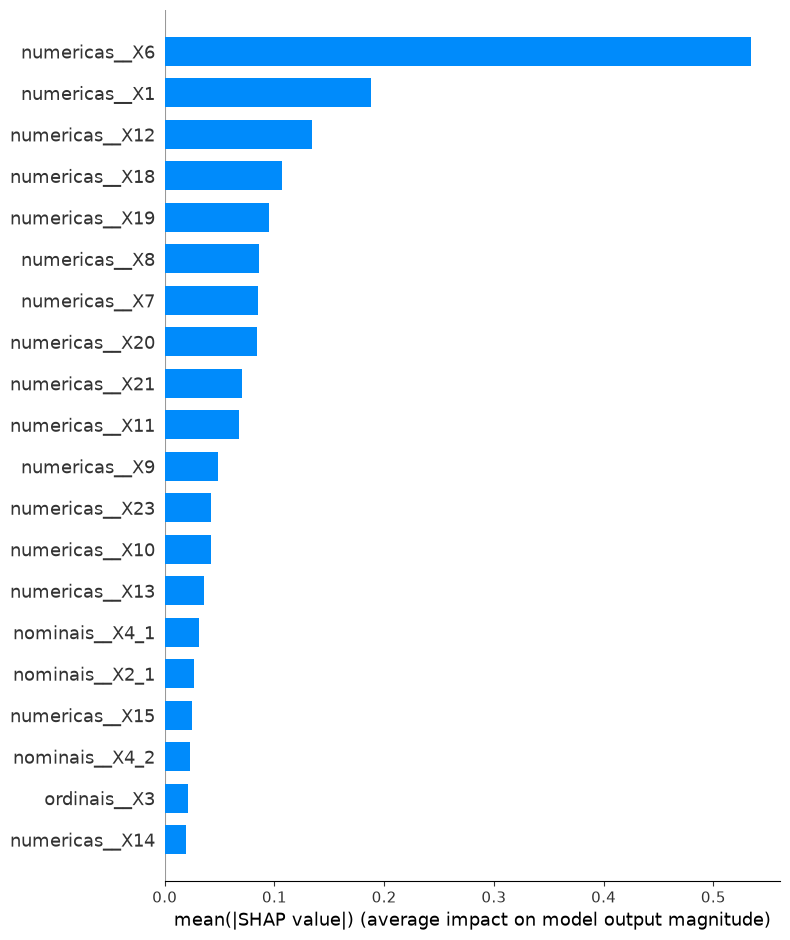

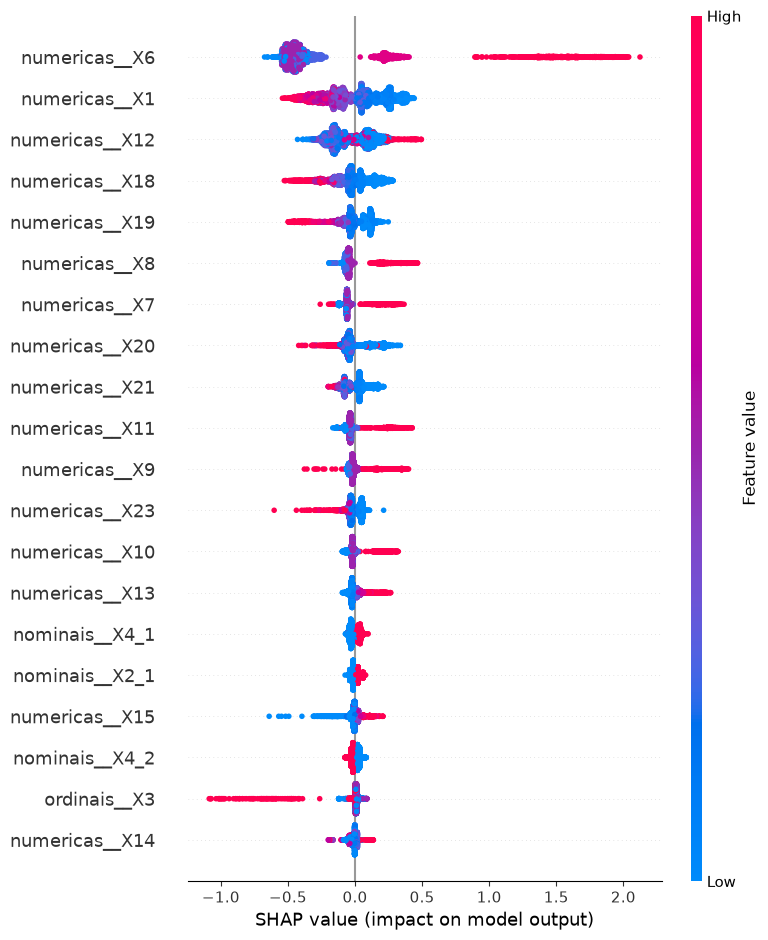

In [47]:
modelo = modelo_xgb.named_steps["modelo"]
preprocessador_treinado = modelo_xgb.named_steps["preprocessamento"]

X_train_transformado = preprocessador_treinado.transform(X_train)
X_test_transformado = preprocessador_treinado.transform(X_test)

nomes_features = preprocessador_treinado.get_feature_names_out()

# Cálculo do SHAP centralizado em src/interpretability.py
explainer, shap_values = calcular_shap_values(modelo, X_test_transformado)

plot_resumo_shap(shap_values, X_test_transformado, nomes_features, tipo="bar")
plot_resumo_shap(shap_values, X_test_transformado, nomes_features, tipo=None)


In [48]:
importancias = modelo.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importance": importancias
})

df_importancia = df_importancia.sort_values("importance", ascending=False)

display(df_importancia.head(30))


,feature,importance
2,numericas__X6,0.380251
3,numericas__X7,0.092182
4,numericas__X8,0.063545
5,numericas__X9,0.051729
15,numericas__X19,0.047508
6,numericas__X10,0.041901
17,numericas__X21,0.041720
14,numericas__X18,0.031921
7,numericas__X11,0.031481
0,numericas__X1,0.028599


## Verificaçao de **fairness/viés**

In [49]:
metrics = {
    'accuracy': accuracy_score,
    'precision': precision_score,
    'selection_rate': selection_rate, # Proportion of predicted positive outcomes
    'count': count
}

# 2. Build the MetricFrame to disaggregate metrics by sensitive features
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_xgb_otimo,
    sensitive_features=X_test[['X2']]
)

# 3. View metrics broken down by each demographic group
print("--- Metrics by Subgroup ---")
print(metric_frame.by_group)

# 4. Check disparities (difference between the max and min group values)
print("\n--- Disparity Metrics ---")
print(f"Accuracy Difference: {metric_frame.difference()['accuracy']:.4f}")
print(f"Selection Rate Difference: {metric_frame.difference()['selection_rate']:.4f}")

# X4
metric_frame = MetricFrame(
    metrics=metrics,
    y_true=y_test,
    y_pred=y_pred_xgb_otimo,
    sensitive_features=X_test[['X4']]
)

print("--- Metrics by Subgroup ---")
print(metric_frame.by_group)


print("\n--- Disparity Metrics ---")
print(f"Accuracy Difference: {metric_frame.difference()['accuracy']:.4f}")
print(f"Selection Rate Difference: {metric_frame.difference()['selection_rate']:.4f}")

--- Metrics by Subgroup ---
    accuracy  precision  selection_rate   count
X2                                             
1   0.556604   0.334989        0.604202  2332.0
2   0.598197   0.317671        0.534827  3661.0

--- Disparity Metrics ---
Accuracy Difference: 0.0416
Selection Rate Difference: 0.0694
--- Metrics by Subgroup ---
    accuracy  precision  selection_rate   count
X4                                             
1   0.581277   0.345888        0.578012  2756.0
2   0.585120   0.306936        0.545397  3172.0
3   0.461538   0.272727        0.676923    65.0

--- Disparity Metrics ---
Accuracy Difference: 0.1236
Selection Rate Difference: 0.1315


o valor de x6 correspondete ao pagamneto mais recente apresenta forte associação com os casos de inadinplencia 


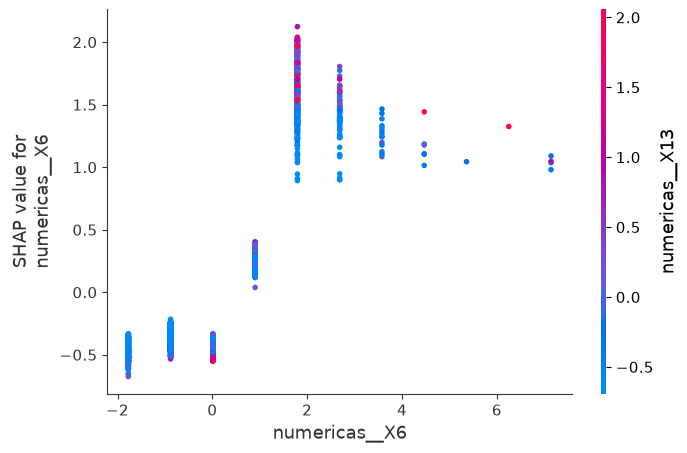

In [50]:
plot_dependencia_shap("numericas__X6", shap_values, X_test_transformado, nomes_features)


vealores baixos de X6 (entre -2 e 0) têm um impacto negativo na previsão (valores SHAP em torno de -0.5). Conforme X6 aumenta e passa de 1, o seu impacto se torna fortemente positivo, saltando para valores SHAP entre 1.0 e 2.0.


In [ ]:
plot_dependencia_shap("numericas__X12", shap_values, X_test_transformado, nomes_features)


e possivel verificar de x12 entre -0.5 e 0 sofrem grande intereferencia quanto a presença da variavel x1  onde valores maiores de x1 combinados com tendem a aumentar o shap no modelo 


In [ ]:
plot_dependencia_shap("numericas__X1", shap_values, X_test_transformado, nomes_features)


valores menores de x1 entre -1 e 0 tendem a produzir um shap positivo e a medida que o valor aumenta o shap tende a diminui os maiores valores de x1 geram um shap inferior a -0.4


### verificaçao das classificaçoes



In [51]:
y_real = y_test.squeeze()
y_pred_otimo = y_pred_xgb_otimo  # previsão do modelo final (XGBoost) já com threshold ajustado

idx_tn = y_real.index[(y_real == 0) & (y_pred_otimo == 0)]
idx_fp = y_real.index[(y_real == 0) & (y_pred_otimo == 1)]
idx_fn = y_real.index[(y_real == 1) & (y_pred_otimo == 0)]
idx_tp = y_real.index[(y_real == 1) & (y_pred_otimo == 1)]

print("TN:", len(idx_tn))
print("FP:", len(idx_fp))
print("FN:", len(idx_fn))
print("TP:", len(idx_tp))

resultado = np.where(
    (y_real == 0) & (y_pred_otimo == 0), "TN",
    np.where(
        (y_real == 0) & (y_pred_otimo == 1), "FP",
        np.where(
            (y_real == 1) & (y_pred_otimo == 0), "FN",
            "TP"
        )
    )
)

df_erros = X_test.copy()
df_erros["real"] = y_real
df_erros["previsao"] = y_pred_otimo
df_erros["resultado"] = resultado
df_erros["probabilidade"] = y_prob_xgb

display(df_erros.head())

display(
    df_erros.groupby("resultado")[["X1", "X5", "X6", "X12", "X18"]]
    .mean()
)


TN: 2394
FP: 2273
FN: 232
TP: 1094


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,real,previsao,resultado,probabilidade
8681,50000,2,3,1,43,0,0,0,0,0,...,2000,1500,3500,600,500,4000,0,1,FP,0.364179
24179,240000,1,2,1,31,0,0,0,0,0,...,7648,7900,8000,6500,6900,7000,0,0,TN,0.255886
27755,90000,2,1,2,25,0,0,0,0,0,...,1500,1500,1500,2000,1500,1000,0,1,FP,0.377681
14938,50000,2,2,2,22,0,0,2,0,0,...,4809,0,1200,1500,943,1142,0,1,FP,0.489564
1486,230000,1,1,2,32,0,0,0,0,0,...,10120,20000,10000,5000,5000,5000,0,0,TN,0.103251


,X1,X5,X6,X12,X18
resultado,,,,,
FN,215560.344828,36.008621,-0.469828,84847.250000,9207.853448
FP,126278.046634,35.338759,-0.003960,33220.378795,2632.702156
TN,227531.328321,35.485380,-0.445698,68969.271512,9844.313701
TP,114981.718464,36.256856,0.892139,43263.617916,2490.530165


### falsos negativos


In [ ]:
falsos_negativos = df_erros[df_erros["resultado"] == "FN"]

display(falsos_negativos.head(20))

display(
    falsos_negativos[
        ["X1", "X2", "X3", "X4", "X5",
         "X6", "X7", "X8", "X9", "X10", "X11",
         "X12", "X13", "X14", "X15", "X16", "X17",
         "X18", "X19", "X20", "X21", "X22", "X23", "probabilidade"]
    ].describe()
)


#### falso negativo


In [ ]:
indice = idx_fn[0]
posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])

print("Exemplo de Falso Negativo")
explicar_caso(explainer, shap_values, X_test_transformado, posicao, nomes_features)

df_linha = pd.DataFrame(df_erros.iloc[posicao]).reset_index()
display(df_linha)


#### verdadeiro positivo


In [ ]:
indice = idx_tp[0]
posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])

print("Exemplo de Verdadeiro Positivo")
explicar_caso(explainer, shap_values, X_test_transformado, posicao, nomes_features)

df_linha = pd.DataFrame(df_erros.iloc[posicao]).reset_index()
display(df_linha)


#### falso positivo:


In [ ]:
indice = idx_fp[0]
posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])

print("Exemplo de Falso Positivo")
explicar_caso(explainer, shap_values, X_test_transformado, posicao, nomes_features)

df_linha = pd.DataFrame(df_erros.iloc[posicao]).reset_index()
display(df_linha)


#### verdadeiro negativo


In [ ]:
indice = idx_tn[0]
posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])

print("Exemplo de Verdadeiro Negativo")
explicar_caso(explainer, shap_values, X_test_transformado, posicao, nomes_features)

df_linha = pd.DataFrame(df_erros.iloc[posicao]).reset_index()
display(df_linha)


### comparaçao FN x TP

| Variável | TP — index 29080 | FN — index 10710 | Diferença / observação |
| :--- | :--- | :--- | :--- |
| **X1 — Limite de crédito** | 120.000 | 150.000 | FN possui limite maior |
| **X2 — Sexo** | 2 | 2 | Igual |
| **X3 — Educação** | 2 | 2 | Igual |
| **X4 — Estado civil** | 1 | 1 | Igual |
| **X5 — Idade** | 54 | 44 | FN é 10 anos mais jovem |
| **X6 — Histórico pagamento** | 1 | -1 | Grande diferença |
| **X7 — Histórico pagamento** | -2 | -1 | Diferença |
| **X8 — Histórico pagamento** | -2 | -1 | Diferença |
| **X9 — Histórico pagamento** | -2 | -1 | Diferença |
| **X10 — Histórico pagamento** | -1 | -1 | Igual |
| **X11 — Histórico pagamento** | -1 | -1 | Igual |
| **X12 — Fatura** | -200 | 390 | Diferença |
| **X13 — Fatura** | -200 | 5.104 | Diferença grande |
| **X14 — Fatura** | -200 | 10.318 | Diferença grande |
| **X15 — Fatura** | 0 | 5.775 | Diferença grande |
| **X16 — Fatura** | 700 | 14.441 | Diferença grande |
| **X17 — Fatura** | 1.935 | 780 | Diferença |
| **X18 — Pagamento anterior** | 0 | 5.104 | Diferença |
| **X19 — Pagamento anterior** | 0 | 10.318 | Diferença |
| **X20 — Pagamento anterior** | 200 | 10.355 | Diferença grande |
| **X21 — Pagamento anterior** | 700 | 14.441 | Diferença grande |
| **X22 — Pagamento anterior** | 1.935 | 780 | Diferença |
| **X23 — Pagamento anterior** | 0 | 66.950 | Diferença muito grande |
| **Real** | 1 | 1 | Ambos inadimplentes |
| **Previsão** | 1 | 0 | TP vs. FN |
| **Probabilidade** | 0,558 | 0,222 | TP acima do threshold 0,34; FN abaixo |
| **Resultado** | TP | FN | Modelo acertou vs. errou |


### persistencia do modelo 

In [52]:
DIR_MODELOS = Path("../models")
DIR_MODELOS.mkdir(exist_ok=True)

artefato = {
    "pipeline": modelo_xgb,              # Pipeline completo (preprocessador + modelo)
    "threshold": melhor_threshold_xgb,   # threshold otimizado via F2-score
    "metricas_teste": metricas_xgb,      # métricas no conjunto de teste, para referência
}

joblib.dump(artefato, DIR_MODELOS / "modelo_final_xgb.joblib")

['..\\models\\modelo_final_xgb.joblib']